In [1]:
# ============================================
# SECTION 1: DATA PREPARATION
# ============================================

import pandas as pd

# Create the dataset
data = {
    "Product": ["Laptop", "Phone", "Tablet", "Monitor", "Keyboard", "Mouse"],
    "Category": ["Computer", "Mobile", "Mobile", "Computer", "Accessory", "Accessory"],
    "Price": [800, 600, 350, 300, 80, 40],
    "Sales": [25, 50, 35, 30, 80, 100],
    "Rating": [4.5, 4.7, 4.2, 4.3, 4.6, 4.4]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
df

,Product,Category,Price,Sales,Rating
0,Laptop,Computer,800,25,4.5
1,Phone,Mobile,600,50,4.7
2,Tablet,Mobile,350,35,4.2
3,Monitor,Computer,300,30,4.3
4,Keyboard,Accessory,80,80,4.6
5,Mouse,Accessory,40,100,4.4


In [6]:
# 1. Display the first five rows
df.head()

# 2. Display the number of rows and columns
df.shape

# 3. Display information about the dataset
df.info()

# 4. Generate descriptive statistics
df.describe()

# 5. Check the number of products in each category
df["Category"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Product   6 non-null      str    
 1   Category  6 non-null      str    
 2   Price     6 non-null      int64  
 3   Sales     6 non-null      int64  
 4   Rating    6 non-null      float64
dtypes: float64(1), int64(2), str(2)
memory usage: 372.0 bytes


Category
Computer     2
Mobile       2
Accessory    2
Name: count, dtype: int64

In [7]:
# ============================================
# SECTION 2: SEABORN ANALYSIS
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

# Set visualization style
sns.set_theme(style="whitegrid")

### Sales by Product

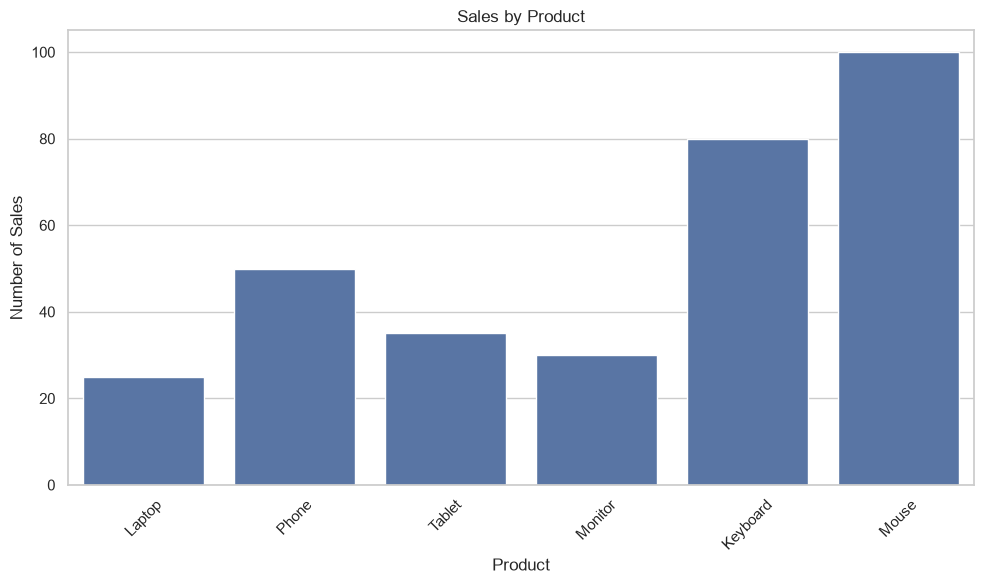

Highest-selling product: Mouse - 100 units
Lowest-selling product: Laptop - 25 units
Difference: 75 units


In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Product",
    y="Sales"
)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Product with the highest sales
highest_sales = df.loc[df["Sales"].idxmax(), "Product"]
highest_sales_value = df["Sales"].max()

# Product with the lowest sales
lowest_sales = df.loc[df["Sales"].idxmin(), "Product"]
lowest_sales_value = df["Sales"].min()

# Difference between highest and lowest sales
sales_difference = highest_sales_value - lowest_sales_value

print("Highest-selling product:", highest_sales, "-", highest_sales_value, "units")
print("Lowest-selling product:", lowest_sales, "-", lowest_sales_value, "units")
print("Difference:", sales_difference, "units")

### Business interpretation:

- The Mouse has the highest sales with 100 units, while the Laptop has the lowest sales with 25 units. 
- The difference is 75 units. This suggests that lower-cost products may have a much larger sales volume in this dataset. 
- Management should investigate whether price, customer demand, product type, or marketing is responsible for this difference.

### Price Vs Sales

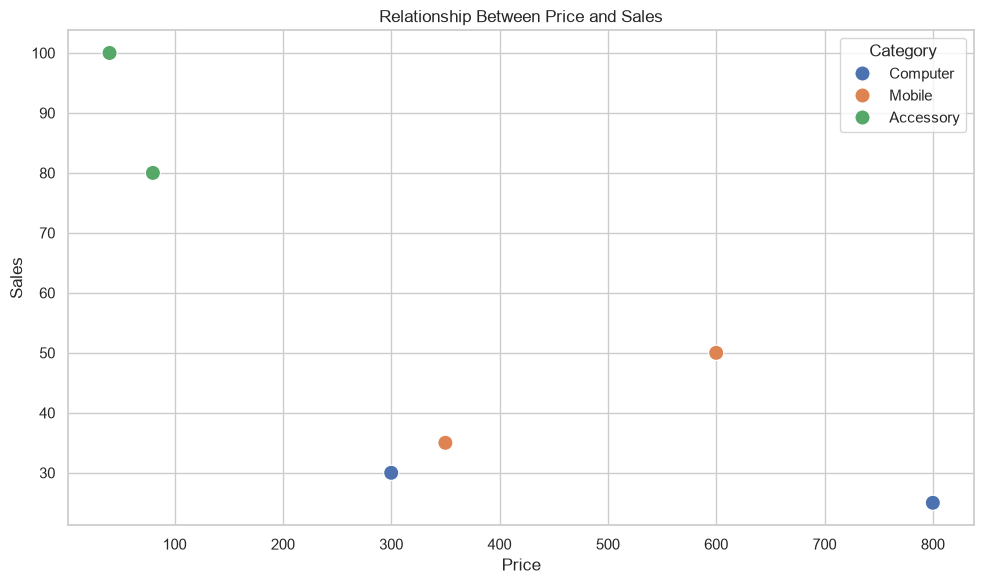

,Product,Price,Sales,Category
5,Mouse,40,100,Accessory
4,Keyboard,80,80,Accessory
3,Monitor,300,30,Computer
2,Tablet,350,35,Mobile
1,Phone,600,50,Mobile
0,Laptop,800,25,Computer


In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Price",
    y="Sales",
    hue="Category",
    s=120
)

plt.title("Relationship Between Price and Sales")
plt.xlabel("Price")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

# Display products sorted by price
df[["Product", "Price", "Sales", "Category"]].sort_values("Price")

### Answers:

- There appears to be a negative relationship between price and sales. The lower-priced products generally have higher sales.
- Yes. In this small dataset, the lower-priced products generally have higher sales.
- The Laptop appears unusual because it has the highest price but the lowest sales.
- No. We cannot conclude that higher prices cause lower sales. The chart only shows an association. Other factors - - such as demand, marketing, discounts, product popularity, and customer preferences could also affect sales.

### Product Price Distribution

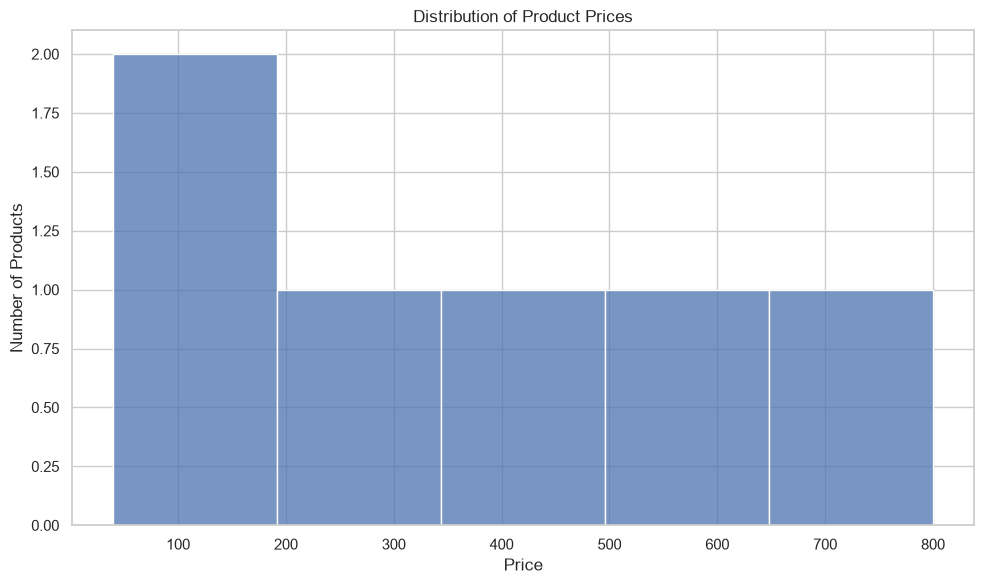

Minimum price: 40
Maximum price: 800


In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Price",
    bins=5
)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()


minimum_price = df["Price"].min()
maximum_price = df["Price"].max()

print("Minimum price:", minimum_price)
print("Maximum price:", maximum_price)

#### Answers:

- The minimum product price is 40.
- The maximum product price is 800.
- Most products are concentrated in the lower price range.
- Yes. The Laptop, at 800, appears unusually expensive compared with most of the other products.
- Management could consider maintaining competitive pricing for lower-priced products while investigating whether expensive products need discounts, better marketing, or additional value propositions.

### Price by Category

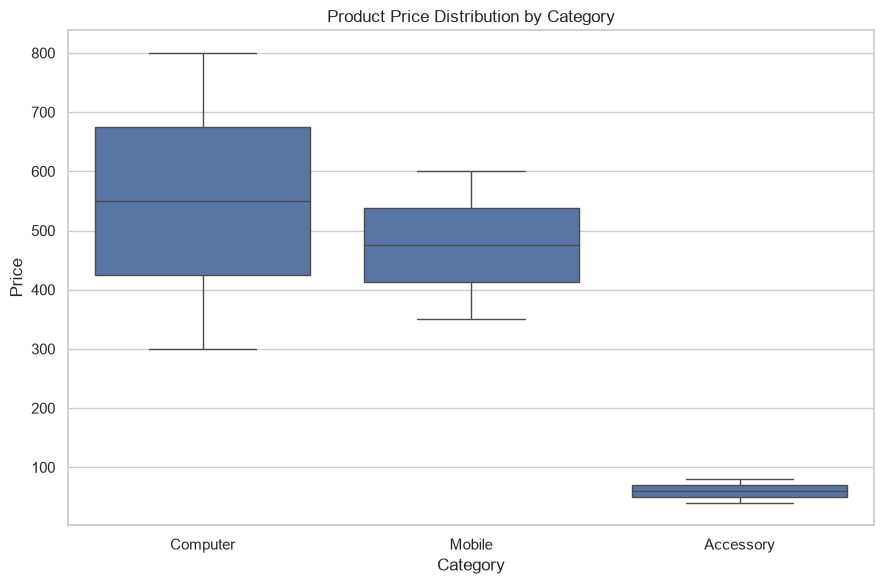

In [14]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Price"
)

plt.title("Product Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

### Answers:

- The Computer category has the highest-priced products.
- The Accessory category has the lowest-priced products.
- The box plot shows how prices vary within each category. Computer products have a much wider price range than Accessories.
- The Laptop appears to be a potential outlier because its price is considerably higher than the other products.
- A major limitation is that each category contains only a small number of products. Therefore, the box plot may not reliably represent the true price distribution of each category.

In [15]:
# ============================================
# SECTION 3: PLOTLY ANALYSIS
# ============================================

import plotly.express as px

#### Interactive Price vs Sales

In [17]:
fig = px.scatter(
    df,
    x="Price",
    y="Sales",
    color="Category",
    hover_name="Product",
    hover_data=["Rating"],
    title="Interactive Price vs Sales Analysis",
    labels={
        "Price": "Product Price",
        "Sales": "Number of Sales"
    }
)

fig.show()

print("Highest sales:")
print(df.loc[df["Sales"].idxmax(), ["Product", "Sales"]])

print("\nHighest price:")
print(df.loc[df["Price"].idxmax(), ["Product", "Price"]])

print("\nHighest rating:")
print(df.loc[df["Rating"].idxmax(), ["Product", "Rating"]])

Highest sales:
Product    Mouse
Sales        100
Name: 5, dtype: object

Highest price:
Product    Laptop
Price         800
Name: 0, dtype: object

Highest rating:
Product    Phone
Rating       4.7
Name: 1, dtype: object


#### Answers:

- The Mouse has the highest sales at 100 units.
- The Laptop has the highest price at 800.
- The Phone has the highest rating at 4.7.
- No. The Phone has the highest rating, but the Mouse has the highest sales.
- Plotly provides interactive features such as hovering over individual products to see their names and ratings. This makes it easier to investigate individual observations than with a basic static chart.

#### Interactive Sales Chart

In [20]:
fig = px.bar(
    df,
    x="Product",
    y="Sales",
    color="Category",
    hover_name="Product",
    hover_data=["Category", "Sales"],
    title="Interactive Product Sales by Category",
    labels={
        "Product": "Product",
        "Sales": "Number of Sales",
        "Category": "Category"
    }
)

fig.show()

# Calculate total sales by category
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

# Display the category with the highest total sales
strongest_category = category_sales.idxmax()
strongest_category_sales = category_sales.max()

print(
    "Strongest sales category:",
    strongest_category,
    "-",
    strongest_category_sales,
    "units"
)

Strongest sales category: Accessory - 180 units


#### Answers:

- The Accessory category has the strongest sales performance with 180 units.
- The Mouse contributes the most to this performance with 100 units.
- Management should investigate the Computer category because its products have relatively low sales compared with their higher prices.
- As a sales manager, I would ask: "Why are the higher-priced Computer products selling significantly fewer units than the lower-priced Accessories?"

### Business Analysis

In [ ]:
# Question 1:  Most important finding
df.sort_values("Sales", ascending=False)[
    ["Product", "Price", "Sales", "Rating"]
]

,Product,Price,Sales,Rating
5,Mouse,40,100,4.4
4,Keyboard,80,80,4.6
1,Phone,600,50,4.7
2,Tablet,350,35,4.2
3,Monitor,300,30,4.3
0,Laptop,800,25,4.5


#### Answer:

- The most important finding is that lower-priced products have significantly higher sales volumes than the expensive products. 
- The Mouse has the highest sales at 100 units, while the Laptop has the lowest sales at 25 units. The Laptop is also the most expensive product at 800. This suggests that price may be associated with sales volume, although other factors may also explain the difference.

Question 2

Answer:
- I would recommend that management investigate the Laptop further. 
- It has the highest price of 800 but the lowest sales of only 25 units. 
- This creates a significant difference compared with products such as the Mouse, which sells 100 units at only 40. 
- Management should investigate whether the Laptop's price, marketing, demand, competition, or customer preferences are affecting its sales.

Question 3

Answer:

- Yes, price appears to be associated with sales in this dataset. 
- The scatter plot suggests that products with lower prices generally have higher sales, while the more expensive products have lower sales. However, this does not prove that price causes lower sales. 
- Additional information such as discounts, marketing expenditure, customer demand, and competitor prices would be needed to investigate the relationship further.

Question 4

Answer:

- Product rating does not appear to have a strong relationship with sales in this dataset. 
- The Phone has the highest rating of 4.7 but does not have the highest sales. The Mouse has the highest sales of 100 units with a rating of 4.4. This suggests that a higher rating does not necessarily result in higher sales.

Question 5

Answer:

Before making a final recommendation, I would request additional data such as:

- Discount percentage — to determine whether discounts affect sales.
- Marketing expenditure — to measure the effect of advertising and promotion.
- Number of customers — to understand the size of the customer base.
- Sales location — to identify differences in demand between locations.
- Competitor prices — to determine whether our products are competitively priced.
- Monthly sales — to identify sales trends over time.
- Product stock levels — to determine whether low sales are caused by limited availability.
- Customer reviews — to understand customer satisfaction beyond numerical ratings.

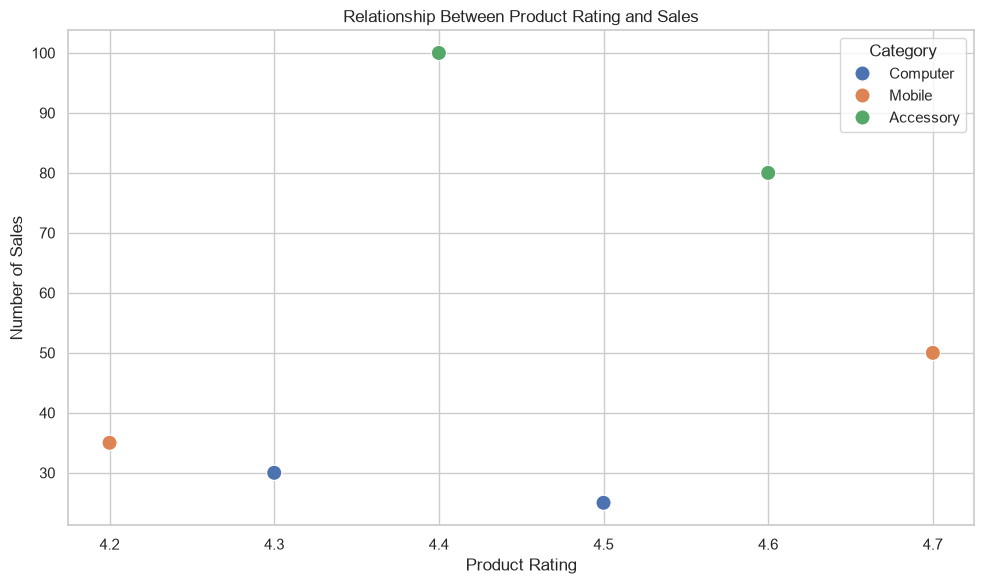

In [22]:
# ============================================
# SECTION 5: CHALLENGE TASK
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Rating",
    y="Sales",
    hue="Category",
    s=120
)

plt.title("Relationship Between Product Rating and Sales")
plt.xlabel("Product Rating")
plt.ylabel("Number of Sales")

plt.tight_layout()
plt.show()

Explanation

I selected a scatter chart because it allows me to examine the relationship between product rating and sales and determine whether highly rated products appear to sell more.

Three observations
- The Phone has the highest rating of 4.7, but it does not have the highest sales.
- The Mouse has the highest sales of 100 units despite having a rating of 4.4.
- The ratings are relatively close together, ranging from 4.2 to 4.7, while sales vary considerably from 25 to 100 units. This suggests that rating alone may not explain the large differences in sales.

In [23]:
# ============================================
# FINAL BUSINESS SUMMARY
# ============================================

print("""
BUSINESS SUMMARY

The analysis shows that lower-priced products generally achieve higher
sales volumes in this dataset. The Mouse is the best-selling product,
while the Laptop has the highest price and the lowest sales.

The Laptop should therefore be investigated further to understand whether
its high price, marketing strategy, customer demand, or competition is
affecting its performance.

Although price appears to be associated with sales, the analysis does not
prove that price causes lower sales. Additional data such as discounts,
marketing expenditure, customer numbers, sales location, competitor prices,
and sales trends would provide a stronger basis for management decisions.
""")


BUSINESS SUMMARY

The analysis shows that lower-priced products generally achieve higher
sales volumes in this dataset. The Mouse is the best-selling product,
while the Laptop has the highest price and the lowest sales.

The Laptop should therefore be investigated further to understand whether
its high price, marketing strategy, customer demand, or competition is
affecting its performance.

Although price appears to be associated with sales, the analysis does not
prove that price causes lower sales. Additional data such as discounts,
marketing expenditure, customer numbers, sales location, competitor prices,
and sales trends would provide a stronger basis for management decisions.

